# 🔍 Anomaly Detection — Notebook 1/2
## Foundations, Taxonomy & Classical Methods
### Data Engineering · 4.5 h Lecture Series

---

**Estimated time:** ~2.5 h | **Audience:** Last-year Data Engineering students
**Prerequisites:** Python, NumPy/Pandas, basic sklearn, basic probability

---
## Table of Contents
1. [What is Anomaly Detection?](#1)
2. [Taxonomy of Anomalies](#2)
3. [Taxonomy of Methods](#3)
4. [Statistical Methods](#4)
5. [Density-Based Methods (LOF, DBSCAN, KDE)](#5)
6. [Distance-Based Methods (kNN, Mahalanobis)](#6)
7. [Isolation Forest](#7)
8. [One-Class SVM](#8)
9. [Comparative Benchmark](#9)
10. [Exercises](#10)

In [1]:
# Run once in Colab
!pip install -q scikit-learn numpy pandas matplotlib seaborn scipy pyod

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity

np.random.seed(42)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
COLORS = {"normal": "#4C72B0", "anomaly": "#DD4444", "boundary": "#22AA77", "recon": "#EE9900"}
print("All imports OK")

All imports OK


---
<a id='1'></a>
## 1. What is Anomaly Detection?

**Definition (Chandola et al., 2009):**
> Anomaly detection is the problem of finding patterns in data that do **not** conform to expected behaviour.

**Synonyms across fields:**
- *Outlier detection* — statistics
- *Novelty detection* — ML (model trained only on normal data)
- *Fault detection* — industrial engineering
- *Intrusion detection* — cybersecurity
- *Fraud detection* — finance

### Why is it hard?
1. **No universal definition of "normal"** — context-dependent.
2. **Class imbalance** — anomalies are rare by definition.
3. **Evolving normality** — concept drift.
4. **Noise vs anomaly** — not all outliers are interesting.
5. **Curse of dimensionality** — distances lose meaning in high dimensions.

### Key distinction

| Setting | Labels? | Method class |
|---|---|---|
| Supervised | Yes (normal + anomaly) | Classification |
| Semi-supervised | Yes (only normal) | Novelty detection |
| Unsupervised | No | Outlier detection |

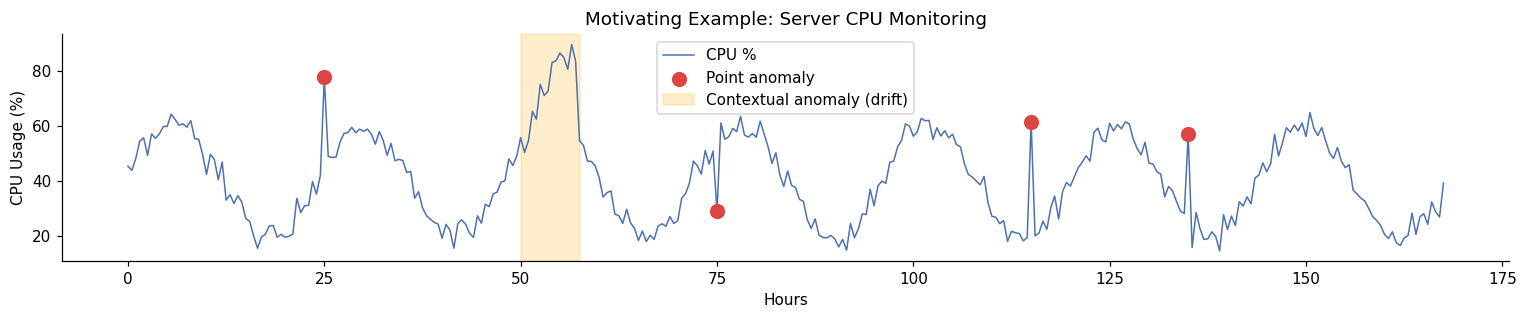

Point anomalies  → single data point far from the rest
Contextual anomaly → value normal in absolute terms, odd given context
Collective anomaly → sequence of points that together are anomalous


In [3]:
# Motivating example: server CPU monitoring
np.random.seed(0)
t = np.arange(0, 7 * 24, 0.5)
cpu = 40 + 20 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 3, len(t))
anomaly_idx = [50, 150, 230, 270]
cpu[anomaly_idx] += [35, -25, 45, 30]
cpu[100:115] += np.linspace(0, 30, 15)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, cpu, color=COLORS["normal"], lw=1, label="CPU %")
ax.scatter(t[anomaly_idx], cpu[anomaly_idx], color=COLORS["anomaly"], zorder=5, s=80, label="Point anomaly")
ax.axvspan(t[100], t[115], alpha=0.2, color="orange", label="Contextual anomaly (drift)")
ax.set_xlabel("Hours"); ax.set_ylabel("CPU Usage (%)")
ax.set_title("Motivating Example: Server CPU Monitoring")
ax.legend(); plt.tight_layout(); plt.show()
print("Point anomalies  → single data point far from the rest")
print("Contextual anomaly → value normal in absolute terms, odd given context")
print("Collective anomaly → sequence of points that together are anomalous")

---
<a id='2'></a>
## 2. Taxonomy of Anomalies

| Type | Description | Example |
|---|---|---|
| **Point anomaly** | Single observation is unusual | Temperature = 80 °C in a 20 °C room |
| **Contextual anomaly** | Unusual given context | 25 °C in winter = anomaly; in summer = normal |
| **Collective anomaly** | A sequence is unusual collectively | 10 consecutive 50 °C readings at a nuclear plant |

**Anomaly score vs binary label:**
Most detectors produce a score $s(x) \in \mathbb{R}$, then threshold:
$$\hat{y}(x) = \mathbf{1}[s(x) > \tau]$$

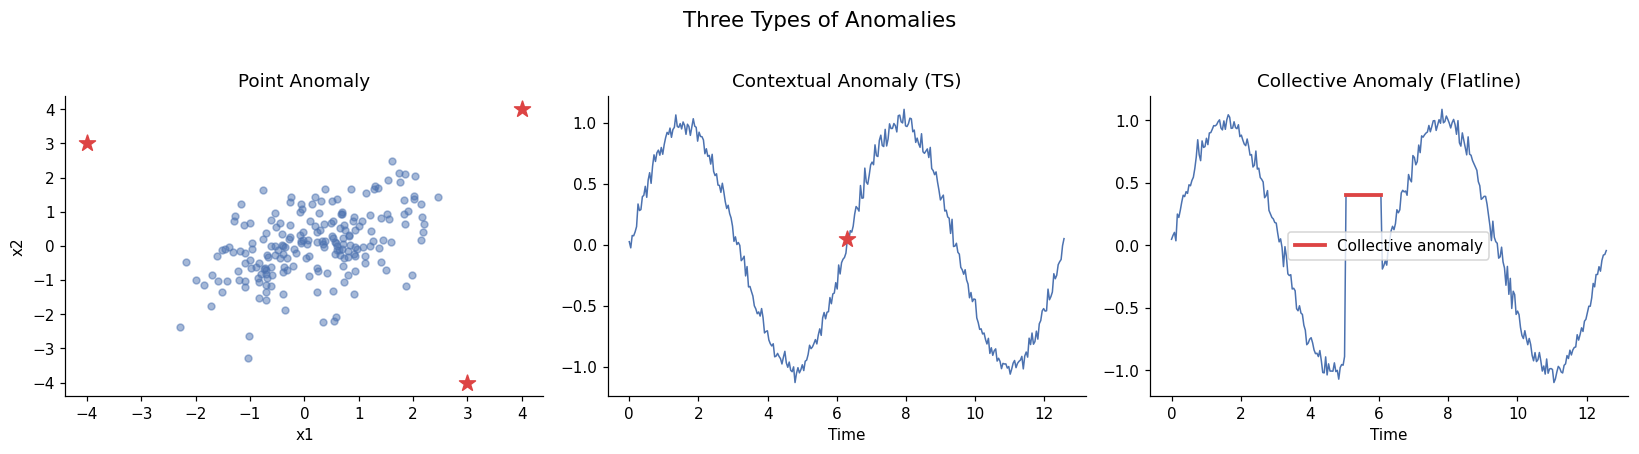

In [4]:
# Visualise the three anomaly types
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Point anomaly
ax = axes[0]
Xn = np.random.multivariate_normal([0, 0], [[1, 0.5], [0.5, 1]], 200)
Xa = np.array([[4, 4], [-4, 3], [3, -4]])
ax.scatter(*Xn.T, c=COLORS["normal"], alpha=0.5, s=20)
ax.scatter(*Xa.T, c=COLORS["anomaly"], s=120, marker="*", zorder=5)
ax.set_title("Point Anomaly"); ax.set_xlabel("x1"); ax.set_ylabel("x2")

# Contextual anomaly
ax = axes[1]
t2 = np.linspace(0, 4 * np.pi, 300)
sig = np.sin(t2) + np.random.normal(0, 0.05, 300)
sig[150] = 0.05
ax.plot(t2, sig, color=COLORS["normal"], lw=1)
ax.scatter(t2[150], sig[150], color=COLORS["anomaly"], s=120, zorder=5, marker="*")
ax.set_title("Contextual Anomaly (TS)"); ax.set_xlabel("Time")

# Collective anomaly
ax = axes[2]
t3 = np.linspace(0, 4 * np.pi, 300)
sig2 = np.sin(t3) + np.random.normal(0, 0.05, 300)
sig2[120:145] = 0.4
ax.plot(t3, sig2, color=COLORS["normal"], lw=1)
ax.plot(t3[120:145], sig2[120:145], color=COLORS["anomaly"], lw=2.5, label="Collective anomaly")
ax.set_title("Collective Anomaly (Flatline)"); ax.set_xlabel("Time"); ax.legend()

plt.suptitle("Three Types of Anomalies", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
<a id='3'></a>
## 3. Taxonomy of Methods

```
Anomaly Detection Methods
├── Statistical
│   ├── Parametric (z-score, Grubbs, Gaussian mixture)
│   └── Non-parametric (histograms, KDE)
├── Proximity-based
│   ├── Distance-based (kNN, Mahalanobis)
│   └── Density-based (LOF, DBSCAN)
├── Classification / Boundary
│   └── One-Class SVM (SVDD)
├── Ensemble / Tree-based
│   └── Isolation Forest
├── Time-Series Specific          → Notebook 2
│   ├── Moving statistics, STL decomposition
│   ├── ARIMA residuals
│   ├── Matrix Profile (DAMP)
│   └── Multivariate TS methods
└── Deep Learning                 → Notebook 2
    ├── Autoencoders / VAE
    ├── LSTM / Transformer-based
    └── GAN-based
```

---
<a id='4'></a>
## 4. Statistical Methods

### 4.1 Z-Score
$$z = \frac{x - \mu}{\sigma}, \quad \text{flag if } |z| > 3$$
**Problem:** mean and std are affected by the very outliers we want to detect.

### 4.2 Modified Z-Score (robust)
$$M_i = \frac{0.6745\,(x_i - \tilde{x})}{\text{MAD}}, \quad \text{flag if } |M_i| > 3.5$$
where $\text{MAD} = \text{median}(|x_i - \tilde{x}|)$.

### 4.3 IQR Rule
Flag $x < Q_1 - 1.5\,\text{IQR}$ or $x > Q_3 + 1.5\,\text{IQR}$.

### 4.4 KDE (non-parametric)
Estimate $p(x)$ without assuming a parametric form; flag $p(x) < \tau$.

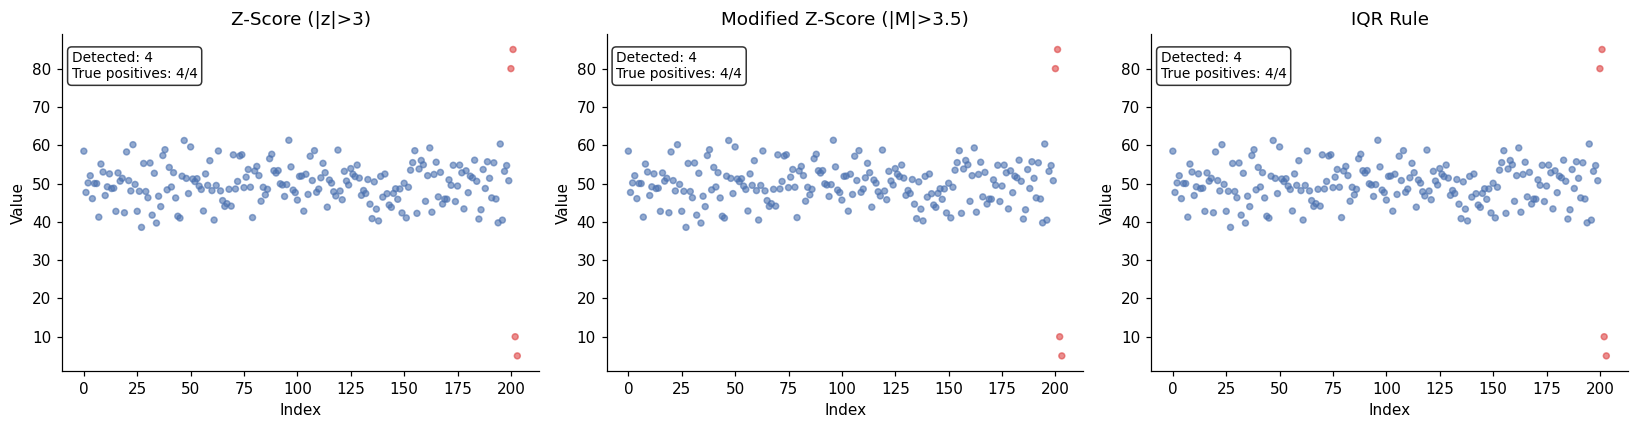

Modified Z-Score / IQR are more robust — prefer them for skewed data


In [5]:
# Statistical methods: Z-score, Modified Z-score, IQR
np.random.seed(7)
normal_data = np.random.normal(50, 5, 200)
outliers = np.array([80, 85, 10, 5])
data = np.concatenate([normal_data, outliers])
true_labels = np.array([0] * 200 + [1] * 4)

# Z-score
mu, sigma = data.mean(), data.std()
z_scores = np.abs((data - mu) / sigma)

# Modified Z-score
median_ = np.median(data)
mad_ = np.median(np.abs(data - median_))
mod_z = np.abs(0.6745 * (data - median_) / (mad_ + 1e-10))

# IQR
Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
IQR = Q3 - Q1
iqr_flags = (data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)

methods = [
    ("Z-Score (|z|>3)", z_scores > 3, z_scores),
    ("Modified Z-Score (|M|>3.5)", mod_z > 3.5, mod_z),
    ("IQR Rule", iqr_flags, None),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, flags, scores) in zip(axes, methods):
    ax.scatter(np.arange(len(data)), data,
               c=[COLORS["anomaly"] if f else COLORS["normal"] for f in flags],
               alpha=0.6, s=15)
    ax.set_title(title); ax.set_xlabel("Index"); ax.set_ylabel("Value")
    tp = (flags & true_labels.astype(bool)).sum()
    ax.text(0.02, 0.95, f"Detected: {flags.sum()}\nTrue positives: {tp}/4",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout(); plt.show()
print("Modified Z-Score / IQR are more robust — prefer them for skewed data")

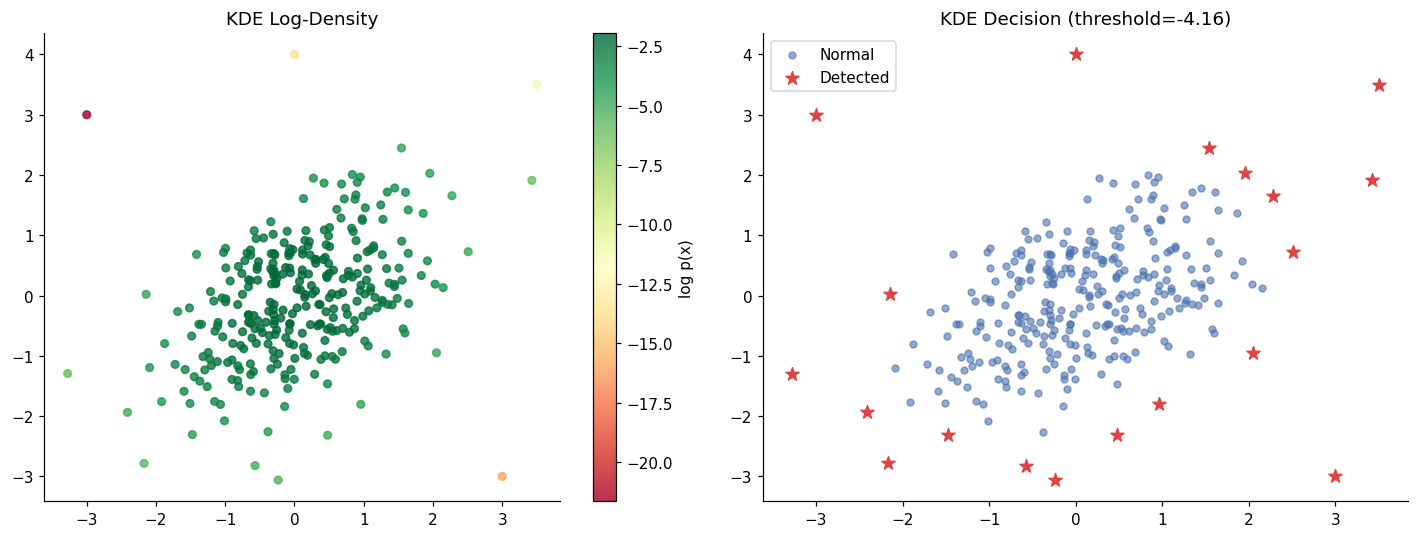

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       300
     Anomaly       0.21      1.00      0.35         4

    accuracy                           0.95       304
   macro avg       0.61      0.97      0.66       304
weighted avg       0.99      0.95      0.97       304



In [6]:
# KDE-based anomaly detection (2D)
X_normal2d = np.random.multivariate_normal([0, 0], [[1, 0.5], [0.5, 1]], 300)
X_anom2d = np.array([[3.5, 3.5], [-3, 3], [3, -3], [0, 4]])
X_all2d = np.vstack([X_normal2d, X_anom2d])
y_all2d = np.array([0] * 300 + [1] * 4)

kde = KernelDensity(kernel="gaussian", bandwidth=0.5).fit(X_normal2d)
log_dens = kde.score_samples(X_all2d)
threshold = np.percentile(kde.score_samples(X_normal2d), 5)
pred_kde = log_dens < threshold

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(*X_all2d.T, c=log_dens, cmap="RdYlGn", s=25, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label="log p(x)")
axes[0].set_title("KDE Log-Density")
axes[1].scatter(*X_all2d[~pred_kde].T, c=COLORS["normal"], s=20, alpha=0.6, label="Normal")
axes[1].scatter(*X_all2d[pred_kde].T, c=COLORS["anomaly"], s=80, marker="*", label="Detected")
axes[1].set_title(f"KDE Decision (threshold={threshold:.2f})"); axes[1].legend()
plt.tight_layout(); plt.show()
print(classification_report(y_all2d, pred_kde.astype(int), target_names=["Normal", "Anomaly"]))

---
<a id='5'></a>
## 5. Density-Based Methods

### Local Outlier Factor — LOF (Breunig et al., 2000)

**Intuition:** a point is anomalous if its local density is much lower than its neighbours'.

1. Find $k$-nearest neighbours $N_k(p)$
2. Reachability distance: $\text{reach-dist}_k(p,o) = \max(k\text{-dist}(o),\, d(p,o))$
3. Local reachability density: $\text{lrd}_k(p) = \left(\frac{\sum_{o\in N_k(p)}\text{reach-dist}_k(p,o)}{|N_k(p)|}\right)^{-1}$
4. $\text{LOF}_k(p) = \frac{1}{|N_k(p)|}\sum_{o\in N_k(p)}\frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}$

$\text{LOF}\approx 1$ → normal; $\text{LOF}\gg 1$ → anomaly.
**Key advantage:** handles clusters of very different densities.

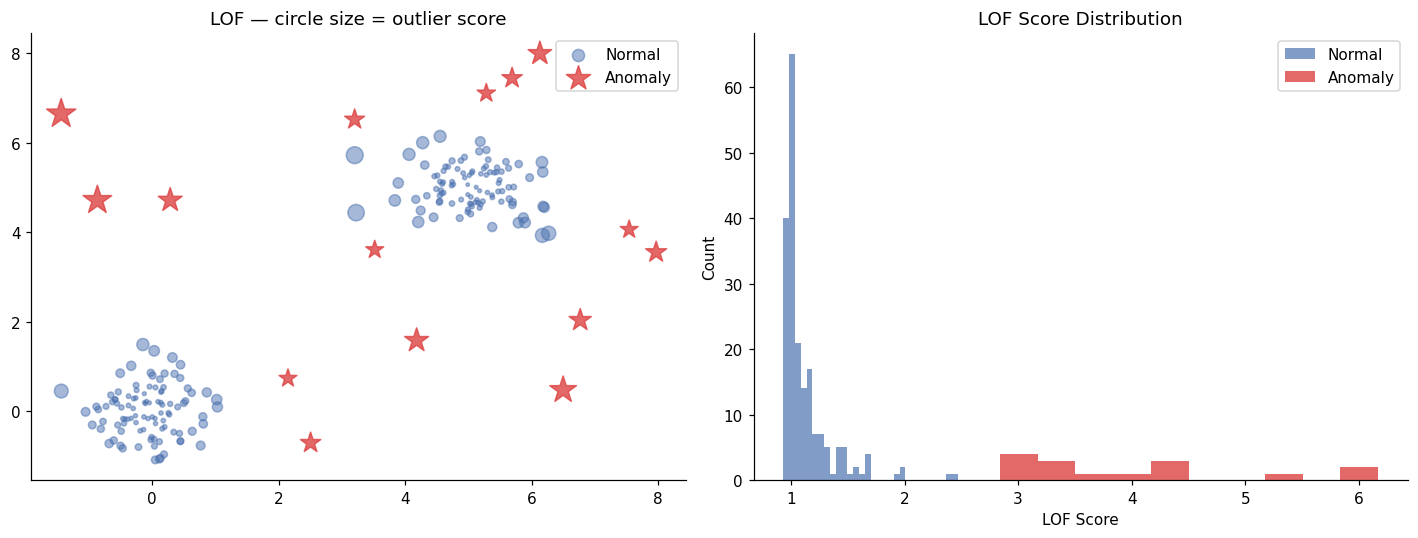

LOF detected 15 anomalies
LOF complexity: O(n^2) naive — use OPTICS/HDBSCAN for large n


In [7]:
# LOF: intuition and implementation
np.random.seed(42)
cluster1 = np.random.multivariate_normal([0, 0], [[0.3, 0], [0, 0.3]], 100)
cluster2 = np.random.multivariate_normal([5, 5], [[0.3, 0], [0, 0.3]], 100)
anomalies_lof = np.random.uniform(-2, 8, (15, 2))
X_lof = np.vstack([cluster1, cluster2, anomalies_lof])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.07)
y_lof = lof.fit_predict(X_lof)
scores_lof = -lof.negative_outlier_factor_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
radius = (scores_lof - scores_lof.min()) / (scores_lof.max() - scores_lof.min()) * 400 + 5
axes[0].scatter(*X_lof[y_lof == 1].T, c=COLORS["normal"], s=radius[y_lof == 1], alpha=0.5, label="Normal")
axes[0].scatter(*X_lof[y_lof == -1].T, c=COLORS["anomaly"], s=radius[y_lof == -1], alpha=0.8, marker="*", label="Anomaly")
axes[0].set_title("LOF — circle size = outlier score"); axes[0].legend()
axes[1].hist(scores_lof[y_lof == 1], bins=30, color=COLORS["normal"], alpha=0.7, label="Normal")
axes[1].hist(scores_lof[y_lof == -1], bins=10, color=COLORS["anomaly"], alpha=0.8, label="Anomaly")
axes[1].set_xlabel("LOF Score"); axes[1].set_ylabel("Count")
axes[1].set_title("LOF Score Distribution"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"LOF detected {(y_lof == -1).sum()} anomalies")
print("LOF complexity: O(n^2) naive — use OPTICS/HDBSCAN for large n")

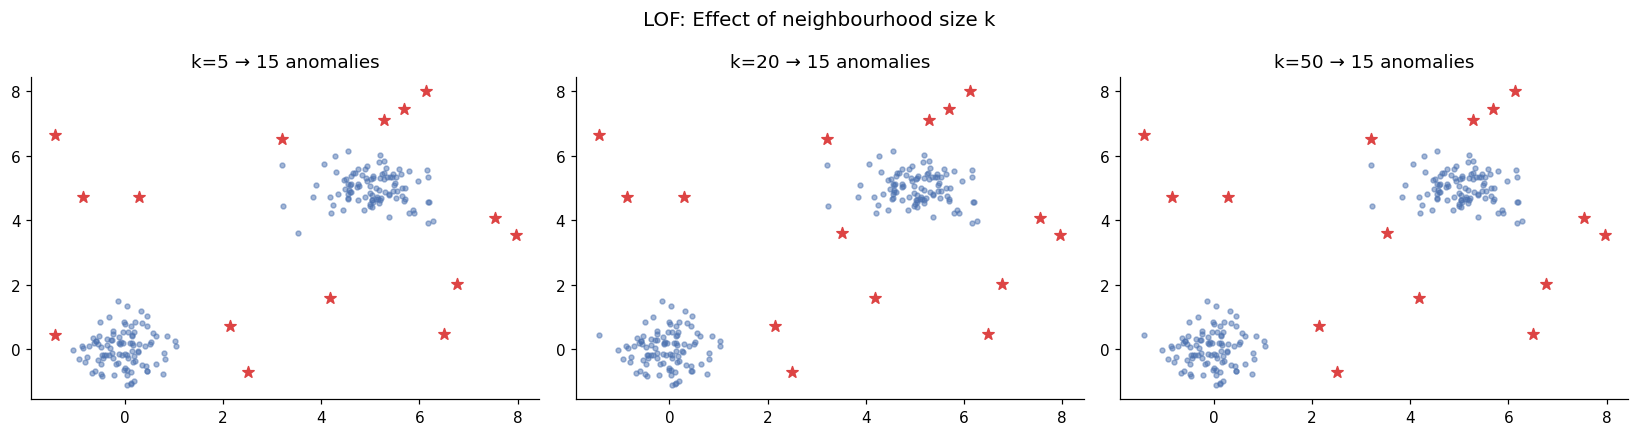

Small k = sensitive to local noise; large k = blurs local structure


In [8]:
# Effect of k on LOF
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [5, 20, 50]):
    lof_k = LocalOutlierFactor(n_neighbors=k, contamination=0.07)
    y_k = lof_k.fit_predict(X_lof)
    ax.scatter(*X_lof[y_k == 1].T, c=COLORS["normal"], s=10, alpha=0.5)
    ax.scatter(*X_lof[y_k == -1].T, c=COLORS["anomaly"], s=60, marker="*")
    ax.set_title(f"k={k} → {(y_k == -1).sum()} anomalies")
plt.suptitle("LOF: Effect of neighbourhood size k", fontsize=13)
plt.tight_layout(); plt.show()
print("Small k = sensitive to local noise; large k = blurs local structure")

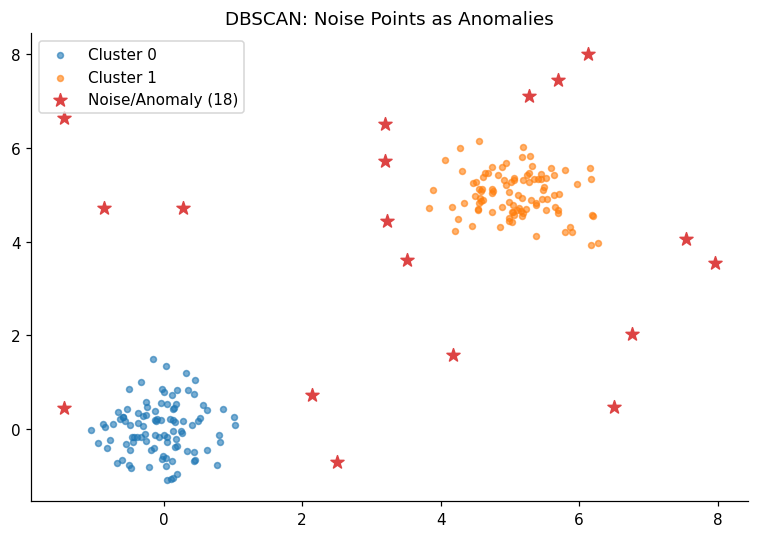

DBSCAN noise points: 18
DBSCAN is very sensitive to eps — use k-dist elbow plot to tune


In [9]:
# DBSCAN for anomaly detection (noise = -1)
db = DBSCAN(eps=0.6, min_samples=5).fit(X_lof)
labels_db = db.labels_
noise = labels_db == -1

fig, ax = plt.subplots(figsize=(7, 5))
for k in set(labels_db) - {-1}:
    m = labels_db == k
    ax.scatter(*X_lof[m].T, s=15, alpha=0.6, label=f"Cluster {k}")
ax.scatter(*X_lof[noise].T, c=COLORS["anomaly"], s=80, marker="*",
           label=f"Noise/Anomaly ({noise.sum()})", zorder=5)
ax.set_title("DBSCAN: Noise Points as Anomalies"); ax.legend()
plt.tight_layout(); plt.show()
print(f"DBSCAN noise points: {noise.sum()}")
print("DBSCAN is very sensitive to eps — use k-dist elbow plot to tune")

---
<a id='6'></a>
## 6. Distance-Based Methods

### kNN anomaly score
$$s(x) = \frac{1}{k}\sum_{i=1}^{k} d(x, x^{(i)})$$

### Mahalanobis Distance
$$D_M(x) = \sqrt{(x-\mu)^T \Sigma^{-1}(x-\mu)}$$
Under a multivariate Gaussian, $D_M^2 \sim \chi^2(d)$ → principled threshold.

**Robust variant:** `EllipticEnvelope` uses the Minimum Covariance Determinant (MCD) estimator.

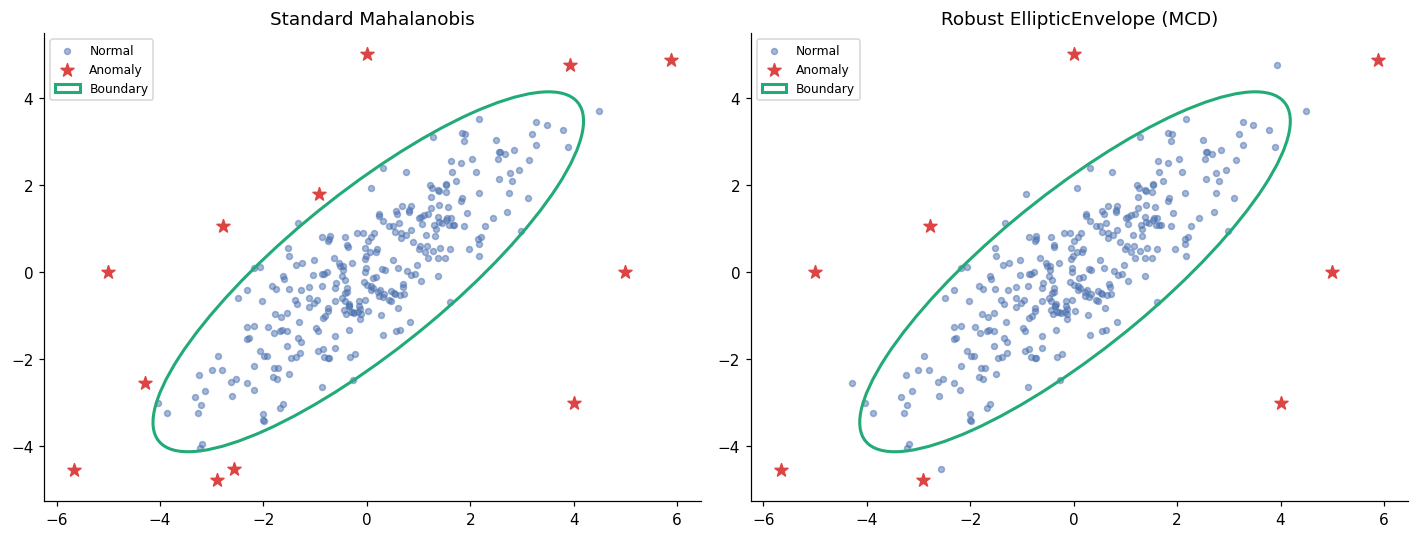

Standard Mahalanobis: 12 | Robust: 8


In [10]:
# Mahalanobis distance vs robust EllipticEnvelope
np.random.seed(42)
Sig = np.array([[3, 2.5], [2.5, 3]])
X_corr = np.random.multivariate_normal([0, 0], Sig, 300)
X_out2 = np.array([[5, 0], [-5, 0], [0, 5], [4, -3]])
X_all3 = np.vstack([X_corr, X_out2])
y_all3 = np.array([0] * 300 + [1] * 4)

mu_hat = X_corr.mean(0)
Sig_hat = np.cov(X_corr.T)
Sig_inv = np.linalg.inv(Sig_hat)
maha = np.array([mahalanobis(x, mu_hat, Sig_inv) ** 2 for x in X_all3])
maha_pred = maha > chi2.ppf(0.975, df=2)

ee = EllipticEnvelope(contamination=0.013, support_fraction=0.95)
ee.fit(X_corr)
ee_pred = ee.predict(X_all3) == -1

from matplotlib.patches import Ellipse
def draw_ellipse(ax, mean, cov, n_std=2.448, color="green", label=""):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=w, height=h, angle=theta,
                  edgecolor=color, facecolor="none", lw=2, label=label)
    ax.add_patch(ell)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, pred) in zip(axes, [
    ("Standard Mahalanobis", maha_pred),
    ("Robust EllipticEnvelope (MCD)", ee_pred)
]):
    ax.scatter(*X_all3[~pred].T, c=COLORS["normal"], s=15, alpha=0.5, label="Normal")
    ax.scatter(*X_all3[pred].T, c=COLORS["anomaly"], s=80, marker="*", label="Anomaly")
    draw_ellipse(ax, mu_hat, Sig_hat, color=COLORS["boundary"], label="Boundary")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Standard Mahalanobis: {maha_pred.sum()} | Robust: {ee_pred.sum()}")

---
<a id='7'></a>
## 7. Isolation Forest (Liu et al., 2008)

**Core insight:** Anomalies are *few* and *different* → they are isolated by fewer random splits.

**Algorithm:**
1. Build an ensemble of random trees by recursively selecting a random feature and random split value.
2. Anomaly score based on average path length $h(x)$:
$$s(x,n) = 2^{-E[h(x)]/c(n)}$$
where $c(n) = 2H(n-1) - 2(n-1)/n$ is the expected path length.

- $s \to 1$ → anomaly | $s \approx 0.5$ → normal

**Advantages:** $O(n \log n)$, no distance computation, scales to millions of points.

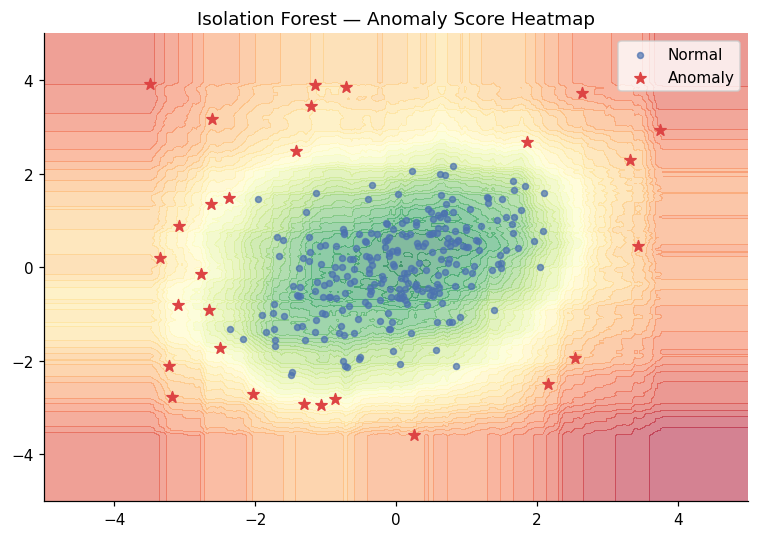

In [11]:
# Isolation Forest: 2D heatmap
np.random.seed(42)
X2dn = np.random.multivariate_normal([0, 0], [[1, 0.5], [0.5, 1]], 250)
X2da = np.random.uniform(-4, 4, (30, 2))
X2d = np.vstack([X2dn, X2da])

iforest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iforest.fit(X2d)
pred2d = iforest.predict(X2d)

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
Z = -iforest.score_samples(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(xx, yy, Z, levels=50, cmap="RdYlGn_r", alpha=0.5)
ax.scatter(*X2d[pred2d == 1].T, c=COLORS["normal"], s=15, alpha=0.7, label="Normal")
ax.scatter(*X2d[pred2d == -1].T, c=COLORS["anomaly"], s=60, marker="*", label="Anomaly")
ax.set_title("Isolation Forest — Anomaly Score Heatmap"); ax.legend()
plt.tight_layout(); plt.show()

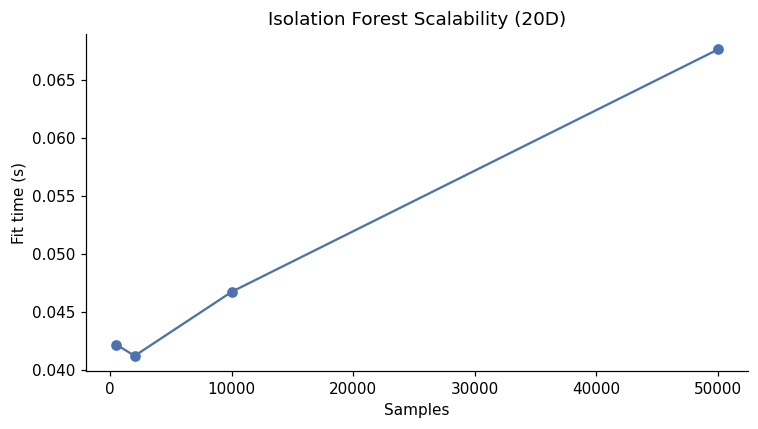

Scales approximately linearly — usable on large datasets


In [12]:
# Isolation Forest: scalability
import time
sizes = [500, 2000, 10000, 50000]
times = []
for n in sizes:
    Xb = np.random.randn(n, 20)
    t0 = time.time()
    IsolationForest(n_estimators=100, random_state=42).fit(Xb)
    times.append(time.time() - t0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, times, "o-", color=COLORS["normal"])
ax.set_xlabel("Samples"); ax.set_ylabel("Fit time (s)")
ax.set_title("Isolation Forest Scalability (20D)")
plt.tight_layout(); plt.show()
print("Scales approximately linearly — usable on large datasets")

---
<a id='8'></a>
## 8. One-Class SVM (Schölkopf et al., 1999)

**Idea:** learn a hypersphere (or hyperplane in kernel space) enclosing the normal training data.

**Optimisation:**
$$\min_{w,\xi_i,\rho}\;\frac{1}{2}\|w\|^2 - \rho + \frac{1}{\nu n}\sum_i \xi_i$$

- $\nu \in (0,1]$: upper bound on fraction of training outliers / lower bound on support vectors.
- **RBF kernel**: maps to infinite-dimensional feature space → complex decision boundaries.
- $f(x) < 0$ → anomaly.

**Weakness:** $O(n^2)$–$O(n^3)$ training → doesn't scale beyond ~50 k samples.

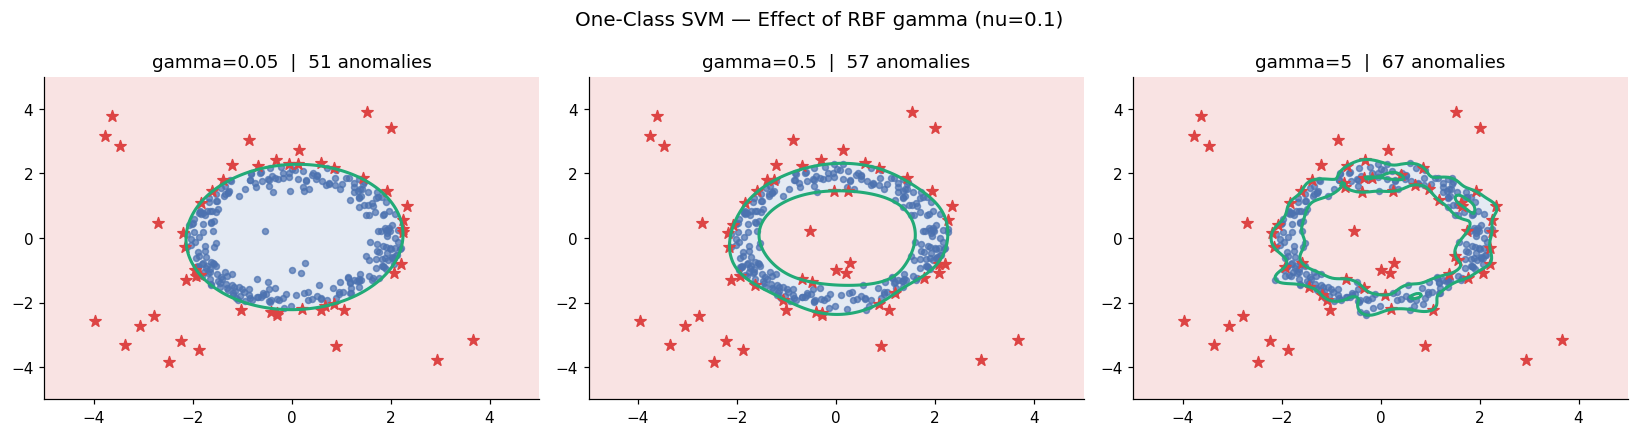

Small gamma -> smooth boundary (underfitting)
Large gamma -> tight spiky boundary (overfitting)


In [13]:
# OC-SVM: ring-shaped data, effect of gamma
np.random.seed(0)
theta = np.random.uniform(0, 2 * np.pi, 300)
r = np.random.normal(2, 0.2, 300)
X_ring = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
X_ring_all = np.vstack([X_ring, np.random.uniform(-4, 4, (30, 2))])

xx3, yy3 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid3 = np.c_[xx3.ravel(), yy3.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, gamma in zip(axes, [0.05, 0.5, 5]):
    m = OneClassSVM(kernel="rbf", gamma=gamma, nu=0.1)
    m.fit(X_ring)
    Z3 = m.decision_function(grid3).reshape(xx3.shape)
    pred3 = m.predict(X_ring_all)
    ax.contourf(xx3, yy3, Z3, levels=[-1e6, 0, 1e6],
                colors=[COLORS["anomaly"], COLORS["normal"]], alpha=0.15)
    ax.contour(xx3, yy3, Z3, levels=[0], colors=[COLORS["boundary"]], linewidths=2)
    ax.scatter(*X_ring_all[pred3 == 1].T, c=COLORS["normal"], s=15, alpha=0.7)
    ax.scatter(*X_ring_all[pred3 == -1].T, c=COLORS["anomaly"], s=60, marker="*")
    ax.set_title(f"gamma={gamma}  |  {(pred3==-1).sum()} anomalies")
plt.suptitle("One-Class SVM — Effect of RBF gamma (nu=0.1)", fontsize=13)
plt.tight_layout(); plt.show()
print("Small gamma -> smooth boundary (underfitting)")
print("Large gamma -> tight spiky boundary (overfitting)")

---
<a id='9'></a>
## 9. Comparative Benchmark

### Evaluation Metrics for Anomaly Detection

| Metric | Use case |
|---|---|
| **AUROC** | Overall ranking quality (threshold-free) |
| **AUPRC** | Imbalanced datasets — focuses on rare class |
| **F1 @ threshold** | Specific operating point |

> ⚠️ **Accuracy is misleading** — predicting all-normal gives 99% accuracy with 1% anomaly rate!

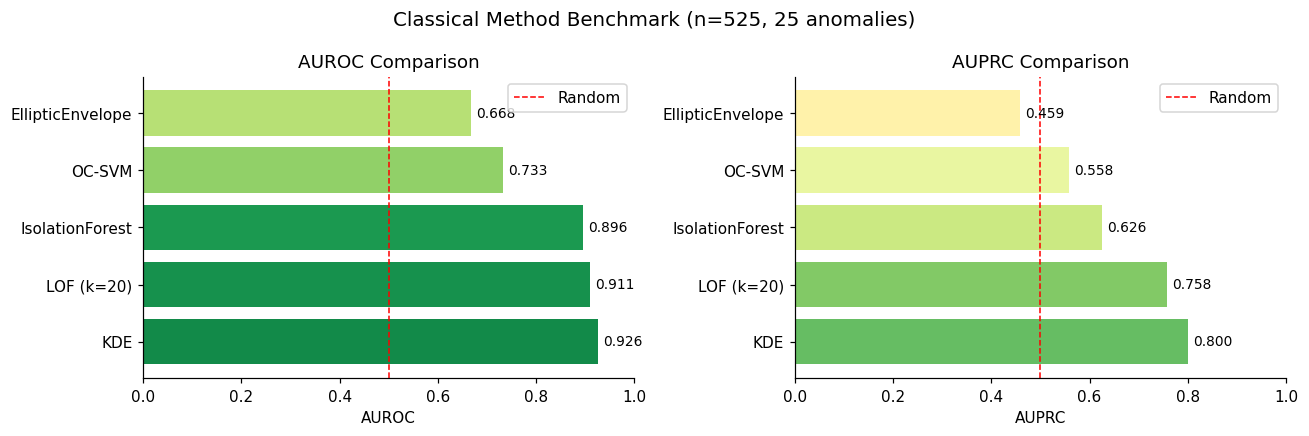

          Method   AUROC    AUPRC
             KDE 0.92608 0.800329
      LOF (k=20) 0.91096 0.757687
 IsolationForest 0.89616 0.626265
          OC-SVM 0.73312 0.557759
EllipticEnvelope 0.66760 0.458634


In [14]:
# Benchmark: all classical methods on the same dataset
np.random.seed(123)
X_bench_n, _ = make_blobs(n_samples=500, centers=[[0,0],[4,0],[2,4],[-2,4],[2,-4]],
                            cluster_std=0.5, random_state=0)
X_bench_a = np.random.uniform(-6, 8, (25, 2))
X_bench = np.vstack([X_bench_n, X_bench_a])
y_bench = np.array([0] * 500 + [1] * 25)

# Compute scores
all_scores = {}

lof_ = LocalOutlierFactor(n_neighbors=20)
lof_.fit_predict(X_bench)
all_scores["LOF (k=20)"] = -lof_.negative_outlier_factor_

ifo_ = IsolationForest(n_estimators=100, contamination="auto", random_state=42)
ifo_.fit(X_bench)
all_scores["IsolationForest"] = -ifo_.score_samples(X_bench)

ocsvm_ = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm_.fit(X_bench_n)
all_scores["OC-SVM"] = -ocsvm_.decision_function(X_bench)

ee_ = EllipticEnvelope(contamination=0.05, support_fraction=0.9)
ee_.fit(X_bench_n)
all_scores["EllipticEnvelope"] = -ee_.decision_function(X_bench)

kde_ = KernelDensity(kernel="gaussian", bandwidth=0.5)
kde_.fit(X_bench_n)
all_scores["KDE"] = -kde_.score_samples(X_bench)

rows = []
for name, sc in all_scores.items():
    rows.append({"Method": name,
                 "AUROC": roc_auc_score(y_bench, sc),
                 "AUPRC": average_precision_score(y_bench, sc)})
df_r = pd.DataFrame(rows).sort_values("AUROC", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pal = plt.cm.RdYlGn
for ax, metric in zip(axes, ["AUROC", "AUPRC"]):
    vals = df_r[metric].values
    bars = ax.barh(df_r["Method"], vals, color=pal(vals))
    ax.set_xlim(0, 1); ax.axvline(0.5, color="red", lw=1, ls="--", label="Random")
    for b, v in zip(bars, vals):
        ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel(metric); ax.set_title(f"{metric} Comparison"); ax.legend()
plt.suptitle("Classical Method Benchmark (n=525, 25 anomalies)", fontsize=13)
plt.tight_layout(); plt.show()
print(df_r.to_string(index=False))

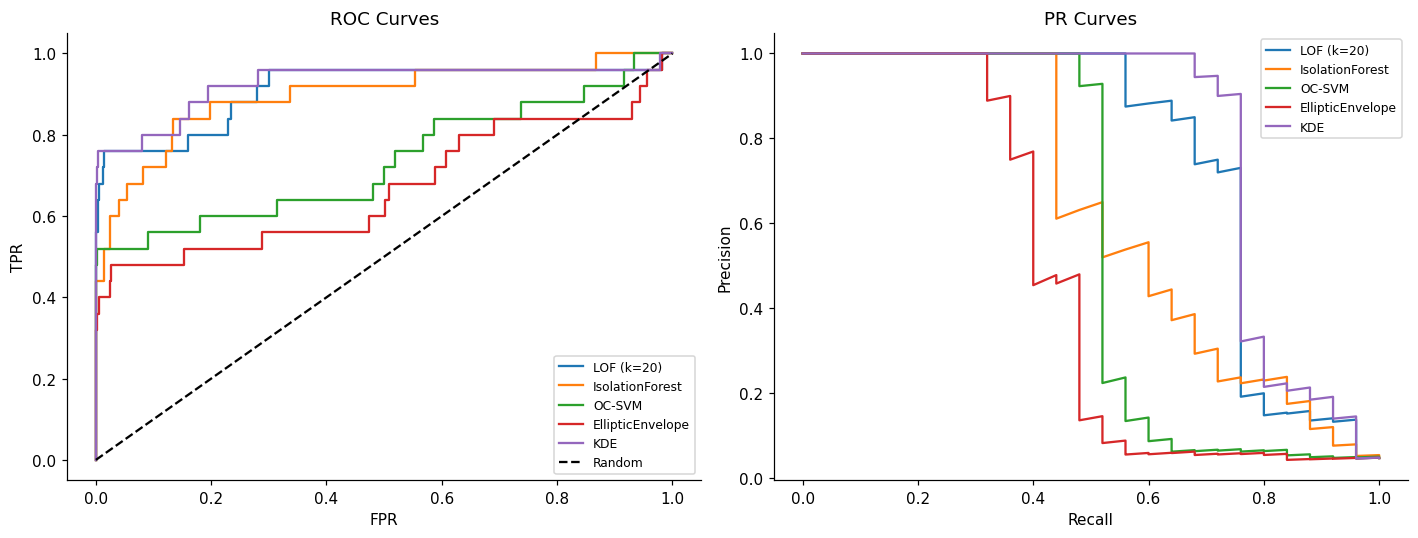

In [15]:
# ROC and Precision-Recall curves for all methods
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_ = plt.cm.tab10.colors
for i, (name, sc) in enumerate(all_scores.items()):
    fpr, tpr, _ = roc_curve(y_bench, sc)
    axes[0].plot(fpr, tpr, color=colors_[i], label=name)
    p, r, _ = precision_recall_curve(y_bench, sc)
    axes[1].plot(r, p, color=colors_[i], label=name)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PR Curves"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
<a id='10'></a>
## 🏋️ Exercises

**Exercise 1 (Warm-up):** Generate a dataset with 3 clusters of very different densities. Show that LOF outperforms standard z-score. Measure AUROC for both.

**Exercise 2 (Medium):** Implement a kNN-based anomaly detector using mean distance to the k nearest neighbours as the anomaly score. Compare its AUROC to LOF on the benchmark.

```python
def knn_anomaly_score(X_train, X_test, k=5):
    # TODO: fit NearestNeighbors, return mean distance to k neighbors for X_test
    from sklearn.neighbors import NearestNeighbors
    ...
```

**Exercise 3 (Hard):** Implement a histogram-based anomaly detector (HBOS):
1. Bin each feature into `n_bins` bins using training data
2. Score each test point as the sum of log-inverse bin frequencies
3. Compare AUROC to IsolationForest and LOF

*Reference: Goldstein & Dengel, HBOS, KI 2012*

**Summary table to fill in after exercises:**

| Method | AUROC (your result) | Notes |
|---|---|---|
| Z-score | | |
| kNN | | |
| LOF | | |
| HBOS | | |
| IsolationForest | | |